# Baby Name Generator with RNN (PyTorch)

This notebook will guide you through creating a simple character-level Recurrent Neural Network (RNN) to generate baby names. The process involves:

1.  **Data Preparation**: Loading names, converting them into numerical representations, and creating input-output pairs.
2.  **Model Definition**: Designing an RNN architecture using PyTorch.
3.  **Training**: Training the RNN to learn character sequences.
4.  **Name Generation**: Using the trained model to generate new, unique baby names.

In [1]:
import torch
import torch.nn as nn
import unicodedata
import string
import random

# All ASCII letters and some punctuation (for simplicity), including an EOS token '$'
all_letters = string.ascii_letters + " .,;'$"
n_letters = len(all_letters)

print(f"Number of characters in vocabulary: {n_letters}")

Number of characters in vocabulary: 58


### Helper Functions for Data Preprocessing

We need functions to:
1.  **Normalize names**: Convert Unicode characters to ASCII.
2.  **Convert a character to a one-hot tensor**: This will be our input to the RNN.
3.  **Convert a name string to a sequence of one-hot tensors**.



In [2]:
# Turn a Unicode string to plain ASCII, thanks to https://stackoverflow.com/a/518232/2809427
def unicode_to_ascii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn' and c in all_letters
    )

# Find letter index from all_letters, e.g. "a" = 0
def letter_to_index(letter):
    return all_letters.find(letter)

# One-hot vector for a letter
def letter_to_tensor(letter):
    tensor = torch.zeros(1, n_letters)
    tensor[0][letter_to_index(letter)] = 1
    return tensor

# One-hot matrix of first to last letters (including EOS)
def name_to_tensor(name):
    tensor = torch.zeros(len(name) + 1, 1, n_letters) # +1 for EOS token
    for i, letter in enumerate(name):
        tensor[i][0][letter_to_index(letter)] = 1
    tensor[len(name)][0][letter_to_index('$')] = 1 # Add EOS token
    return tensor

print(f"Example: 'ryan' -> Shape: {name_to_tensor('ryan').shape}")
print(f"Example: 'z' -> Value: {letter_to_tensor('z')}")

Example: 'ryan' -> Shape: torch.Size([5, 1, 58])
Example: 'z' -> Value: tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0.]])


### Load the Dataset

For this task, we need a list of baby names. You can either provide a `.txt` file with one name per line, or we can use a simple hardcoded list for demonstration.

I'll create a placeholder list here. If you have a file, modify the `names` variable below to load from your file.

In [3]:
# Placeholder for baby names. Replace this with your actual dataset loading.
# Example: If you have a 'babynames.txt' file:
# with open('babynames.txt', 'r') as f:
#     names = [unicode_to_ascii(line.strip()) for line in f if line.strip()]

names = [
    'Aaliyah', 'Abdullah', 'Aisha', 'Ali', 'Amara', 'Amin', 'Amina', 'Anaya', 'Arjun', 'Aryan',
    'Ayat', 'Bilal', 'Cyrus', 'Dania', 'Dawood', 'Elias', 'Fatima', 'Fawad', 'Hadi', 'Hafsa',
    'Hamza', 'Hanan', 'Hassan', 'Hina', 'Ibrahim', 'Imran', 'Inaya', 'Iqbal', 'Ishaq', 'Isra',
    'Jameel', 'Jannah', 'Javed', 'Layla', 'Leila', 'Mahnoor', 'Maheen', 'Mahmood', 'Maryam', 'Meena',
    'Mehmet', 'Miraal', 'Mohammad', 'Musa', 'Mustafa', 'Nadia', 'Naima', 'Nasir', 'Omar', 'Osman',
    'Rabia', 'Rahim', 'Rania', 'Rashid', 'Rayyan', 'Rehan', 'Rida', 'Rizwan', 'Ruhab', 'Saad',
    'Saba', 'Safa', 'Safiya', 'Saima', 'Sana', 'Sara', 'Shahid', 'Shazia', 'Sufyan', 'Sumaira',
    'Syed', 'Tahir', 'Taimoor', 'Usman', 'Wajiha', 'Yasmin', 'Zahra', 'Zainab', 'Zaki', 'Zaroon',
    'Zoya', 'Adnan', 'Bushra', 'Danish', 'Farah', 'Ghulam', 'Hoorain', 'Jibran', 'Khadija', 'Laiba',
    'Maha', 'Nida', 'Qasim', 'Ramsha', 'Sameer', 'Tabinda', 'Umar', 'Warda', 'Yusuf', 'Zeeshan'
]

print(f"Loaded {len(names)} names. First 5: {names[:5]}")

Loaded 100 names. First 5: ['Aaliyah', 'Abdullah', 'Aisha', 'Ali', 'Amara']


### Model Definition

We'll use a simple character-level RNN. A Gated Recurrent Unit (GRU) is a good choice for this task as it can capture long-term dependencies in sequences. Our model will take a one-hot encoded character as input and output a probability distribution over the next possible characters.

In [4]:
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size

        self.i2h = nn.Linear(input_size + hidden_size, hidden_size)
        self.i2o = nn.Linear(input_size + hidden_size, output_size)
        self.o2o = nn.Linear(hidden_size + output_size, output_size)
        self.dropout = nn.Dropout(0.1)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input_tensor, hidden_tensor):
        combined = torch.cat((input_tensor, hidden_tensor), 1)
        hidden = self.i2h(combined)
        output = self.i2o(combined)
        output_combined = torch.cat((hidden, output), 1)
        output = self.o2o(output_combined)
        output = self.dropout(output)
        output = self.softmax(output)
        return output, hidden

    def init_hidden(self):
        return torch.zeros(1, self.hidden_size)


# Example of GRU based RNN (more commonly used for this task)
class GRU_RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(GRU_RNN, self).__init__()
        self.hidden_size = hidden_size

        self.gru = nn.GRU(input_size, hidden_size) # Input and hidden size
        self.out = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input_tensor, hidden_tensor):
        # input_tensor is 1, 1, input_size (for character-level) -> needs to be 1, input_size for GRU
        input_tensor = input_tensor.view(1, 1, -1) # Reshape for GRU: seq_len, batch_size, input_size

        output, hidden = self.gru(input_tensor, hidden_tensor)
        output = self.softmax(self.out(output[0])) # output[0] is the output from the last timestep
        return output, hidden

    def init_hidden(self):
        return torch.zeros(1, 1, self.hidden_size) # Shape for GRU: num_layers * num_directions, batch_size, hidden_size


# Instantiate the model
hidden_size = 128
rnn = GRU_RNN(n_letters, hidden_size, n_letters)

print(rnn)

GRU_RNN(
  (gru): GRU(58, 128)
  (out): Linear(in_features=128, out_features=58, bias=True)
  (softmax): LogSoftmax(dim=1)
)


### Training the Model

To train the model, we need:
1.  A way to select random name-to-tensor pairs.
2.  A training function that feeds these pairs to the RNN and updates its weights.
3.  A loss function and an optimizer.


In [5]:
criterion = nn.NLLLoss()
optimizer = torch.optim.Adam(rnn.parameters(), lr=0.005)

def random_training_example():
    name = random.choice(names)
    name_tensor = name_to_tensor(name) # This now includes EOS
    category_tensor = torch.tensor([0], dtype=torch.long) # Category not used in this simple generator, but good practice for other RNNs
    return name, category_tensor, name_tensor

# train function
def train(name_tensor):
    hidden = rnn.init_hidden()
    rnn.zero_grad()

    loss = 0

    for i in range(name_tensor.size(0) - 1): # Iterate up to the second to last character for input
        output, hidden = rnn(name_tensor[i], hidden)
        # Target is the next character in the sequence
        target = torch.argmax(name_tensor[i+1], dim=1)
        loss += criterion(output, target)

    # No need for special handling of the last character as EOS is now part of the tensor and handled by the loop.

    loss.backward()
    optimizer.step()

    return output, loss.item() / (name_tensor.size(0) - 1) # Normalize by actual number of prediction steps

print("Training functions defined.")

Training functions defined.


### Running the Training

We'll run the training for a number of iterations, printing progress and the loss. We will save the model after training.

In [6]:
import time
import math

# Keep track of losses for plotting
current_loss = 0
all_losses = []

def time_since(since):
    now = time.time()
    s = now - since
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

n_iters = 100000 # Number of training iterations
print_every = 5000
plot_every = 5000

start = time.time()

for iter_num in range(1, n_iters + 1):
    _, _, name_tensor = random_training_example()
    output, loss = train(name_tensor)
    current_loss += loss

    # Print iter_number, loss, name
    if iter_num % print_every == 0:
        print(f'{time_since(start)} ({iter_num} {iter_num/n_iters*100:.1f}%) loss {loss:.4f}')

    # Add current loss history to plot
    if iter_num % plot_every == 0:
        all_losses.append(current_loss / plot_every)
        current_loss = 0

print("Training complete!")

0m 26s (5000 5.0%) loss 0.3979
0m 51s (10000 10.0%) loss 0.9007
1m 16s (15000 15.0%) loss 0.2462
1m 41s (20000 20.0%) loss 0.4876
2m 6s (25000 25.0%) loss 0.3373
2m 31s (30000 30.0%) loss 0.3911
2m 56s (35000 35.0%) loss 0.2137
3m 22s (40000 40.0%) loss 0.5273
3m 47s (45000 45.0%) loss 0.5085
4m 13s (50000 50.0%) loss 0.3680
4m 38s (55000 55.0%) loss 0.2531
5m 4s (60000 60.0%) loss 0.2552
5m 29s (65000 65.0%) loss 0.5082
5m 54s (70000 70.0%) loss 0.4147
6m 20s (75000 75.0%) loss 0.1147
6m 46s (80000 80.0%) loss 0.7741
7m 11s (85000 85.0%) loss 0.4567
7m 36s (90000 90.0%) loss 0.1113
8m 1s (95000 95.0%) loss 0.0991
8m 27s (100000 100.0%) loss 0.3236
Training complete!


### Training Loss Visualization

Let's visualize the training loss over iterations to understand the learning progress of the model. A decreasing loss generally indicates that the model is learning effectively.

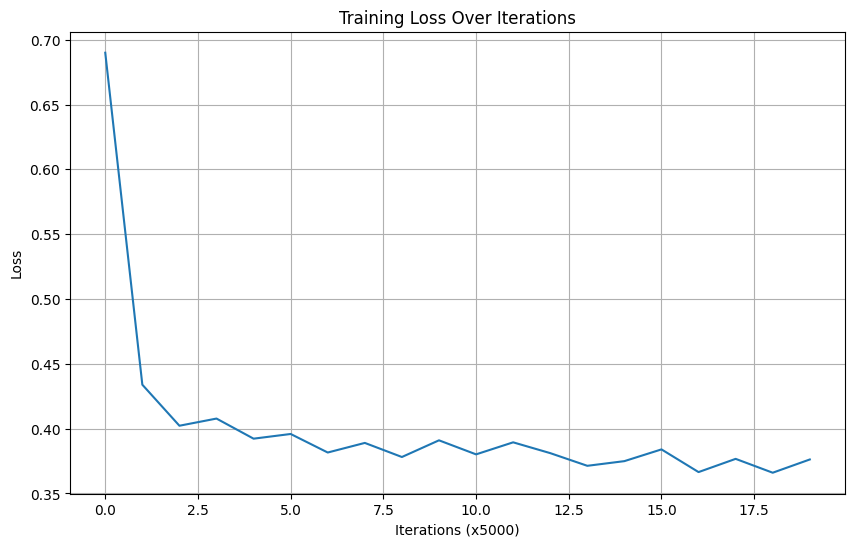

In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(10, 6))
plt.plot(all_losses)
plt.title('Training Loss Over Iterations')
plt.xlabel('Iterations (x{})'.format(plot_every))
plt.ylabel('Loss')
plt.grid(True)
plt.show()

### Generate Names

Finally, we'll use our trained RNN to generate new names. To do this, we'll feed a starting character (or an empty string to start from scratch), and the model will predict the next character. We'll continue this process until an 'End of Sequence' character is predicted or a maximum length is reached.

In [8]:
def generate(start_char='A', temperature=0.8, max_length=20):
    with torch.no_grad():  # No need to track gradients for generation
        hidden = rnn.init_hidden()

        # Start with a user-provided character or a random one
        input_tensor = letter_to_tensor(start_char)
        generated_name = start_char

        for _ in range(max_length):
            output, hidden = rnn(input_tensor, hidden)

            # Apply temperature for sampling
            # Higher temperature makes the model more 'creative' (more random)
            # Lower temperature makes it more 'deterministic' (picks higher probability chars)
            output_dist = output.data.view(-1).div(temperature).exp()
            top_i = torch.multinomial(output_dist, 1)[0]

            # Check if it's an end-of-sequence character
            predicted_char = all_letters[top_i]
            if predicted_char == '$': # Stop generation if EOS token is predicted
                break

            generated_name += predicted_char
            input_tensor = letter_to_tensor(predicted_char)

        return generated_name

print("Generated Names:")
print(generate('A'))
print(generate('S'))
print(generate('M'))
print(generate('Z'))
print(generate('R'))
print(generate('H'))

Generated Names:
Aaliyah
Sufyan
Mustafa
Zeeshan
Rehan
Hassan


# Let's try with two letters

In [9]:
print("Generated Names:")
print(generate('Ab'))
print(generate('Sh'))
print(generate('Mu'))
print(generate('Zo'))


Generated Names:
Abahid
Shahmood
Muayyan
Zoahid


# 3 Letters

In [10]:
print("Generated Names:")
print(generate('Abb'))
print(generate('Shu'))
print(generate('Muh'))
print(generate('Zoy'))


Generated Names:
Abbyat
Shuaryam
Muhatim
Zoyaryan


# Discussion:
THe model performs better when single letters are sent to the generate function. However, when two letters are added it makes up names that do not exist.